# Tugas - Klasifikasi dengan Decision Tree

| Nama | NRP |
| --- | --- |
| Catherine Aprilia Harlina | 5054251012 |

# 1. Persiapan Dataset dan Eksplorasi Awal

### Ringkasan Informasi Dataset

| Metrik                  | Nilai                            |
|:------------------------|:---------------------------------|
| Jumlah Baris (Records)  | 6,819                            |
| Jumlah Kolom (Features) | 96                               |
| Total Missing Value     | 0                                |
| Status Missing Value    | Bersih (Tidak Ada Missing Value) |

### Distribusi Kelas Target (Bankrupt?)

| Kelas Kebangkrutan   |   Jumlah Perusahaan | Persentase   |
|:---------------------|--------------------:|:-------------|
| 0 (Tidak Bangkrut)   |                6599 | 96.77%       |
| 1 (Bangkrut)         |                 220 | 3.23%        |

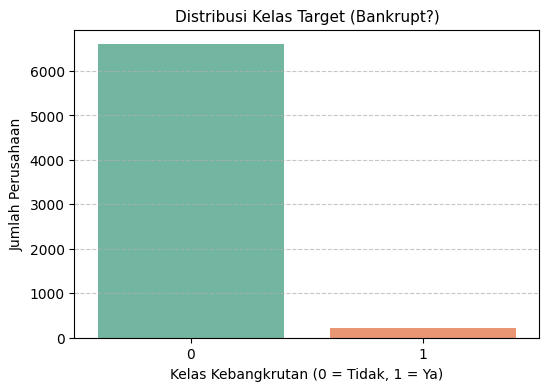

Catatan: Dataset tergolong imbalanced karena 96.77% data berada pada kelas 0 (Tidak Bangkrut).


### Sampel Statistik Deskriptif (5 Fitur Pertama)

,count,mean,std,min,25%,50%,75%,max
ROA(C) before interest and depreciation before interest,6819.0,0.5052,0.0607,0.0,0.4765,0.5027,0.5356,1.0
ROA(A) before interest and % after tax,6819.0,0.5586,0.0656,0.0,0.5355,0.5598,0.5892,1.0
ROA(B) before interest and depreciation after tax,6819.0,0.5536,0.0616,0.0,0.5273,0.5523,0.5841,1.0
Operating Gross Margin,6819.0,0.6079,0.0169,0.0,0.6004,0.6060,0.6139,1.0
Realized Sales Gross Margin,6819.0,0.6079,0.0169,0.0,0.6004,0.6060,0.6138,1.0


### Distribusi Fitur Finansial per Kelas Target (Boxplot)

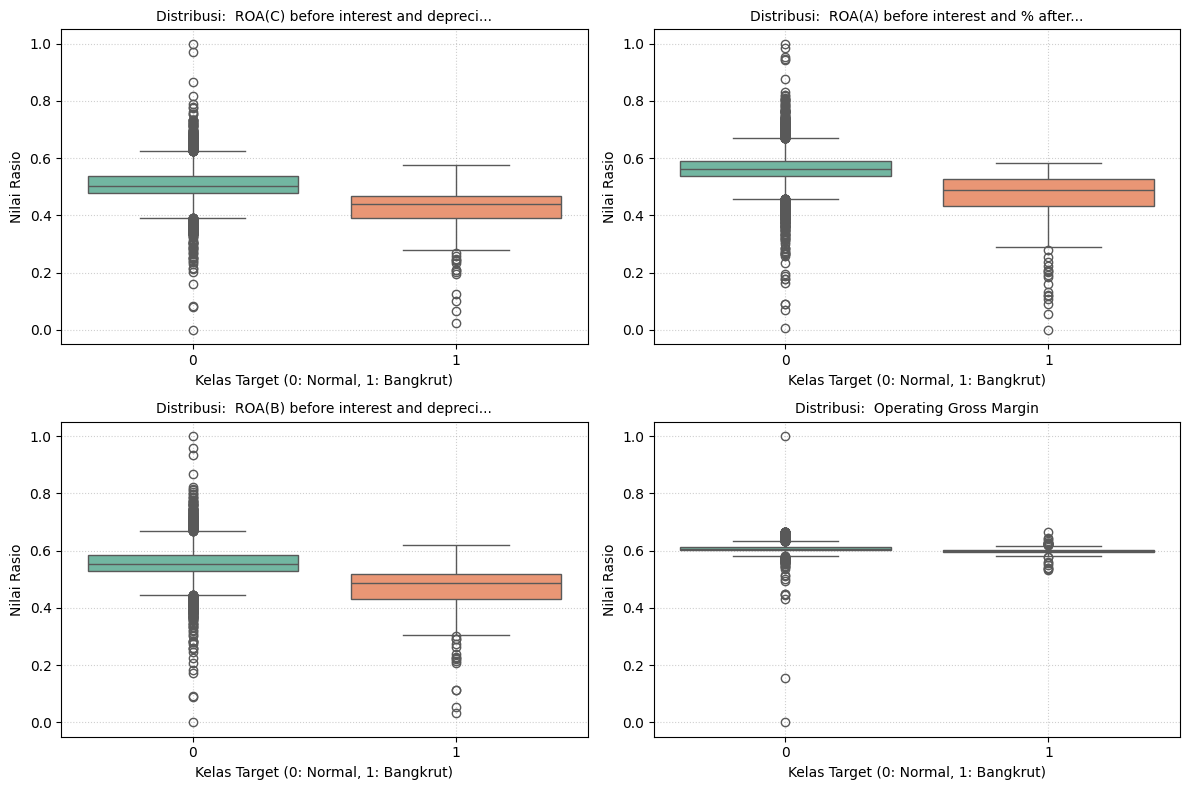

### EDA Tambahan: Top 10 Fitur Paling Berkorelasi dengan Kebangkrutan

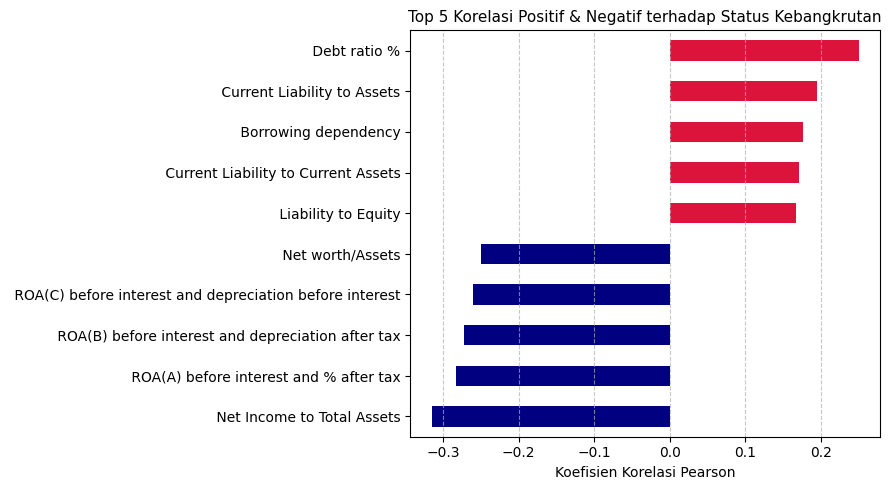

### EDA Tambahan: Ringkasan Outlier pada 5 Fitur Utama (Metode IQR)

| Fitur                                 |   Jumlah Outlier | Persentase Outlier   |
|:--------------------------------------|-----------------:|:---------------------|
| ROA(C) before interest and depreci... |              391 | 5.73%                |
| ROA(A) before interest and % after... |              561 | 8.23%                |
| ROA(B) before interest and depreci... |              432 | 6.34%                |
| Operating Gross Margin                |              320 | 4.69%                |
| Realized Sales Gross Margin           |              318 | 4.66%                |

In [14]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, warnings
from IPython.display import display, Markdown
warnings.filterwarnings('ignore')

df = pd.read_csv('bankruptcy.csv')
target_col = [c for c in df.columns if 'bankrupt' in c.lower()][0]

# --- 1. ringkasan dataset ---
display(Markdown("### Ringkasan Informasi Dataset"))
info_ringkas = pd.DataFrame({'Metrik': ['Jumlah Baris (Records)', 'Jumlah Kolom (Features)', 'Total Missing Value', 'Status Missing Value'], 'Nilai': [f"{df.shape[0]:,}", f"{df.shape[1]}", f"{df.isnull().sum().sum()}", 'Bersih (Tidak Ada Missing Value)']})
display(Markdown(info_ringkas.to_markdown(index=False)))

# --- 2. cek sebaran & analisis imbalanced data ---
display(Markdown("### Distribusi Kelas Target (Bankrupt?)"))
counts, percentages = df[target_col].value_counts(), df[target_col].value_counts(normalize=True) * 100
df_distribusi = pd.DataFrame({'Kelas Kebangkrutan': ['0 (Tidak Bangkrut)', '1 (Bangkrut)'], 'Jumlah Perusahaan': [counts.get(0, 0), counts.get(1, 0)], 'Persentase': [f"{percentages.get(0, 0):.2f}%", f"{percentages.get(1, 0):.2f}%"]})
display(Markdown(df_distribusi.to_markdown(index=False)))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target_col, hue=target_col, palette='Set2', legend=False)
plt.title(f'Distribusi Kelas Target ({target_col})', fontsize=11); plt.xlabel('Kelas Kebangkrutan (0 = Tidak, 1 = Ya)'); plt.ylabel('Jumlah Perusahaan'); plt.grid(axis='y', linestyle='--', alpha=0.7); plt.show()
print(f"Catatan: Dataset tergolong imbalanced karena {percentages.get(0, 0):.2f}% data berada pada kelas 0 (Tidak Bangkrut).")

# --- 3. dokumentasi fitur & statistik deskriptif ---
display(Markdown("### Sampel Statistik Deskriptif (5 Fitur Pertama)"))
display(df.iloc[:, 1:6].describe().T.round(4))

# --- 4. visualisasi distribusi fitur per kelas target ---
display(Markdown("### Distribusi Fitur Finansial per Kelas Target (Boxplot)"))
feature_cols = [c for c in df.columns if c != target_col][:4]
fig, axes = plt.subplots(2, 2, figsize=(12, 8)); axes = axes.flatten()
for i, col in enumerate(feature_cols):
    sns.boxplot(data=df, x=target_col, y=col, hue=target_col, palette='Set2', ax=axes[i], legend=False)
    axes[i].set_title(f"Distribusi: {col[:35] + '...' if len(col) > 35 else col}", fontsize=10); axes[i].set_xlabel('Kelas Target (0: Normal, 1: Bangkrut)'); axes[i].set_ylabel('Nilai Rasio'); axes[i].grid(True, linestyle=':', alpha=0.6)
plt.tight_layout(); plt.show()

# --- 5. eda tambahan: korelasi & outlier ---
display(Markdown("### EDA Tambahan: Top 10 Fitur Paling Berkorelasi dengan Kebangkrutan"))
correlations = df.corr()[target_col].drop(target_col)
top_corr = pd.concat([correlations.nlargest(5), correlations.nsmallest(5)]).sort_values()
plt.figure(figsize=(9, 5)); top_corr.plot(kind='barh', color=['crimson' if x > 0 else 'navy' for x in top_corr]); plt.title('Top 5 Korelasi Positif & Negatif terhadap Status Kebangkrutan', fontsize=11); plt.xlabel('Koefisien Korelasi Pearson'); plt.grid(axis='x', linestyle='--', alpha=0.7); plt.tight_layout(); plt.show()

display(Markdown("### EDA Tambahan: Ringkasan Outlier pada 5 Fitur Utama (Metode IQR)"))
sample_features = [c for c in df.columns if c != target_col][:5]
outlier_list = []
for col in sample_features:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    outliers = df[(df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)]
    outlier_list.append({'Fitur': col[:35] + '...' if len(col) > 35 else col, 'Jumlah Outlier': len(outliers), 'Persentase Outlier': f"{(len(outliers) / len(df)) * 100:.2f}%"})
display(Markdown(pd.DataFrame(outlier_list).to_markdown(index=False)))

In [ ]:
from sklearn.model_selection import train_test_split

# handle missing & encoding
df = df.dropna() if df.isnull().sum().sum() > 0 else df
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True) if categorical_cols else df

X, y = df.drop(columns=[target_col]), df[target_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

display(Markdown("### Ringkasan Pembagian Dataset (Train vs Test)"))
df_split_summary = pd.DataFrame({'Dataset': ['Train Set (80%)', 'Test Set (20%)', 'Total Data'], 'Jumlah Sampel': [f"{X_train.shape[0]:,}", f"{X_test.shape[0]:,}", f"{df.shape[0]:,}"], 'Jumlah Fitur (X)': [X_train.shape[1], X_test.shape[1], X.shape[1]], 'Proporsi Target 0 (%)': [f"{(y_train == 0).mean() * 100:.2f}%", f"{(y_test == 0).mean() * 100:.2f}%", f"{(y == 0).mean() * 100:.2f}%"], 'Proporsi Target 1 (%)': [f"{(y_train == 1).mean() * 100:.2f}%", f"{(y_test == 1).mean() * 100:.2f}%", f"{(y == 1).mean() * 100:.2f}%"]})
display(Markdown(df_split_summary.to_markdown(index=False)))

Konfirmasi: Dataset bersih, tidak ada missing value yang perlu ditangani.
Konfirmasi: Semua fitur dalam dataset sudah berupa numerik (float64/int64), tidak memerlukan encoding tambahan.


### Ringkasan Pembagian Dataset (Train vs Test)

| Dataset         |   Jumlah Sampel |   Jumlah Fitur (X) | Proporsi Target 0 (%)   | Proporsi Target 1 (%)   |
|:----------------|----------------:|-------------------:|:------------------------|:------------------------|
| Train Set (80%) |           5,455 |                 95 | 96.77%                  | 3.23%                   |
| Test Set (20%)  |           1,364 |                 95 | 96.77%                  | 3.23%                   |
| Total Data      |           6,819 |                 95 | 96.77%                  | 3.23%                   |

In [22]:
# 3.1 decision tree (gini)
model_gini = DecisionTreeClassifier(criterion='gini', random_state=42).fit(X_train, y_train)
y_pred_gini = model_gini.predict(X_test)

df_gini_res = pd.DataFrame({
    'Model': ['Decision Tree (Gini)'],
    'Akurasi Training': [f"{accuracy_score(y_train, model_gini.predict(X_train)) * 100:.2f}%"],
    'Akurasi Testing': [f"{accuracy_score(y_test, y_pred_gini) * 100:.2f}%"],
    'Kedalaman Pohon (Depth)': [model_gini.get_depth()],
    'Jumlah Node': [model_gini.get_n_leaves()]
})

display(Markdown(df_gini_res.to_markdown(index=False)))

| Model                | Akurasi Training   | Akurasi Testing   |   Kedalaman Pohon (Depth) |   Jumlah Node |
|:---------------------|:-------------------|:------------------|--------------------------:|--------------:|
| Decision Tree (Gini) | 100.00%            | 96.11%            |                        20 |           124 |

In [23]:
# 3.2 decision tree (entropy)
model_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42).fit(X_train, y_train)
y_pred_entropy = model_entropy.predict(X_test)

df_entropy_res = pd.DataFrame({
    'Model': ['Decision Tree (Entropy)'],
    'Akurasi Training': [f"{accuracy_score(y_train, model_entropy.predict(X_train)) * 100:.2f}%"],
    'Akurasi Testing': [f"{accuracy_score(y_test, y_pred_entropy) * 100:.2f}%"],
    'Kedalaman Pohon (Depth)': [model_entropy.get_depth()],
    'Jumlah Node': [model_entropy.get_n_leaves()]
})

display(Markdown(df_entropy_res.to_markdown(index=False)))

| Model                   | Akurasi Training   | Akurasi Testing   |   Kedalaman Pohon (Depth) |   Jumlah Node |
|:------------------------|:-------------------|:------------------|--------------------------:|--------------:|
| Decision Tree (Entropy) | 100.00%            | 96.41%            |                        17 |            99 |

### Tabel Ringkasan Eksperimen max_depth

| max_depth        | Akurasi Training   | Akurasi Testing   | Selisih / Gap (%)   |
|:-----------------|:-------------------|:------------------|:--------------------|
| 1                | 96.77%             | 96.77%            | -0.00%              |
| 2                | 96.99%             | 96.99%            | -0.00%              |
| 3                | 97.23%             | 96.99%            | 0.24%               |
| 5                | 97.75%             | 96.85%            | 0.90%               |
| 10               | 99.47%             | 96.04%            | 3.43%               |
| None (Unbounded) | 100.00%            | 96.11%            | 3.89%               |

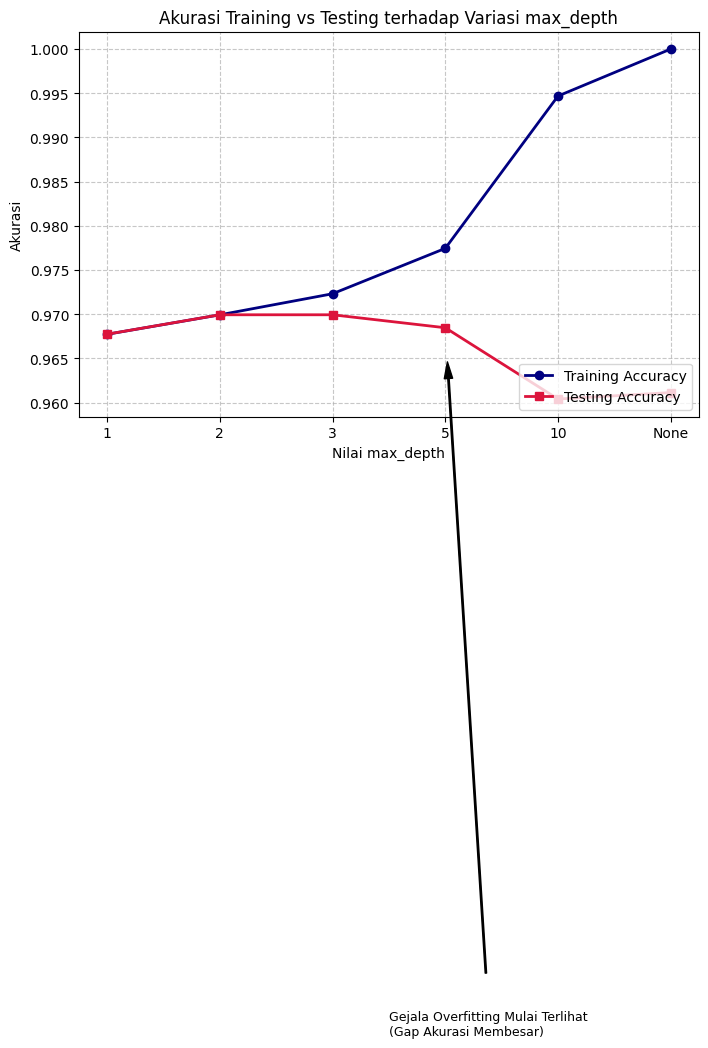

In [24]:
# 3.3 eksperimen regularisasi max_depth
depths = [1, 2, 3, 5, 10, None]
train_acc, test_acc = [], []

for d in depths:
    dt_reg = DecisionTreeClassifier(criterion='gini', max_depth=d, random_state=42).fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, dt_reg.predict(X_train)))
    test_acc.append(accuracy_score(y_test, dt_reg.predict(X_test)))

# tabel ringkasan
df_depth = pd.DataFrame({
    'max_depth': [str(d) if d is not None else 'None (Unbounded)' for d in depths],
    'Akurasi Training': [f"{tr * 100:.2f}%" for tr in train_acc],
    'Akurasi Testing': [f"{ts * 100:.2f}%" for ts in test_acc],
    'Selisih / Gap (%)': [f"{(tr - ts) * 100:.2f}%" for tr, ts in zip(train_acc, test_acc)]
})

display(Markdown("### Tabel Ringkasan Eksperimen max_depth"))
display(Markdown(df_depth.to_markdown(index=False)))

# plot grafik
plt.figure(figsize=(8, 5))
x_labels = [str(d) if d is not None else 'None' for d in depths]
plt.plot(x_labels, train_acc, marker='o', lw=2, label='Training Accuracy', color='navy')
plt.plot(x_labels, test_acc, marker='s', lw=2, label='Testing Accuracy', color='crimson')
plt.title('Akurasi Training vs Testing terhadap Variasi max_depth', fontsize=12)
plt.xlabel('Nilai max_depth', fontsize=10); plt.ylabel('Akurasi', fontsize=10)
plt.legend(loc='lower right'); plt.grid(True, ls='--', alpha=0.7)
plt.annotate('Gejala Overfitting Mulai Terlihat\n(Gap Akurasi Membesar)', xy=(3, test_acc[3]), xytext=(2.5, test_acc[3] - 0.08), arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6), fontsize=9)
plt.tight_layout(); plt.show()

### Tabel Perbandingan Metrik Evaluasi Model

| Model                   | Accuracy        | Precision       | Recall          | F1-Score        |
|:------------------------|:----------------|:----------------|:----------------|:----------------|
| Decision Tree (Gini)    | 0.9611 (96.11%) | 0.4000 (40.00%) | 0.4091 (40.91%) | 0.4045 (40.45%) |
| Decision Tree (Entropy) | 0.9641 (96.41%) | 0.4359 (43.59%) | 0.3864 (38.64%) | 0.4096 (40.96%) |

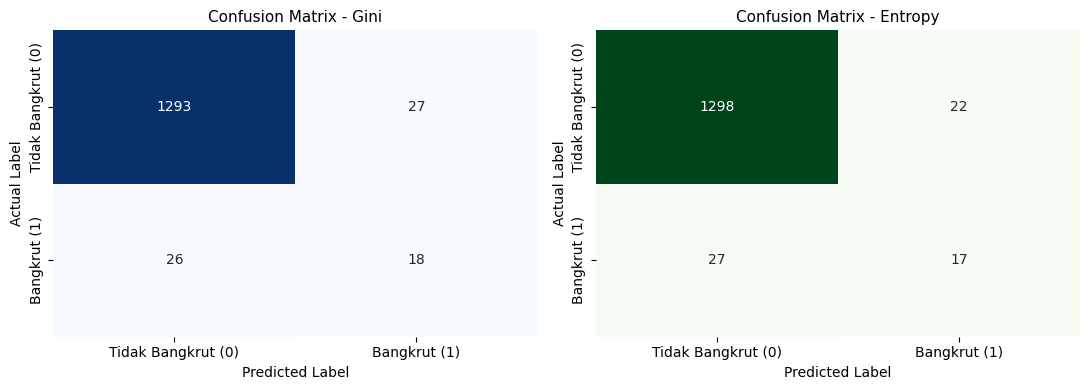

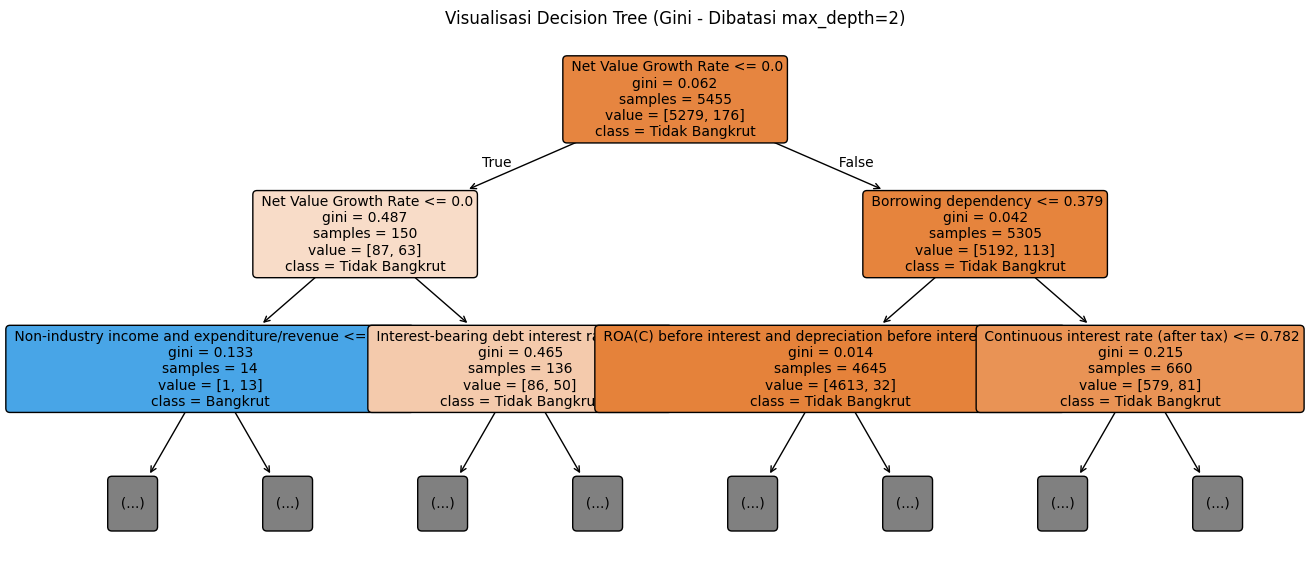

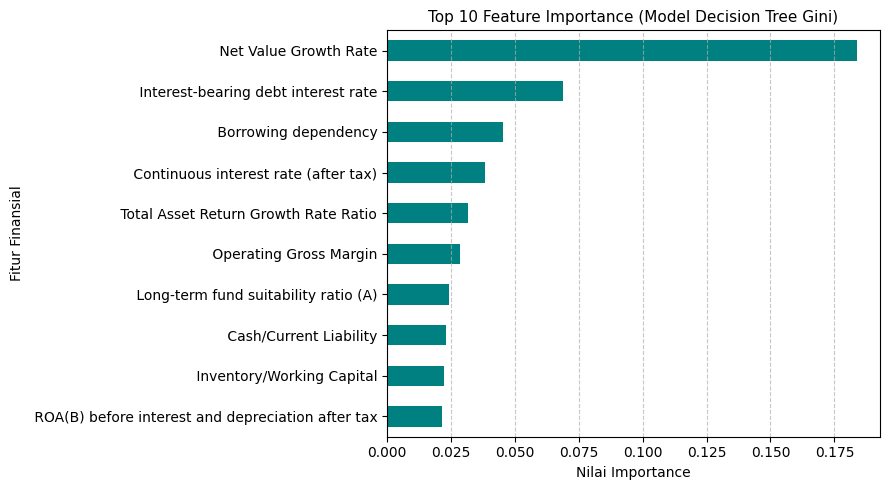

In [26]:
# 4. evaluasi model & visualisasi
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.tree import plot_tree

# 1. tabel metrik evaluasi
metrics_data = {
    'Model': ['Decision Tree (Gini)', 'Decision Tree (Entropy)'],
    'Accuracy': [accuracy_score(y_test, y_pred_gini), accuracy_score(y_test, y_pred_entropy)],
    'Precision': [precision_score(y_test, y_pred_gini, zero_division=0), precision_score(y_test, y_pred_entropy, zero_division=0)],
    'Recall': [recall_score(y_test, y_pred_gini, zero_division=0), recall_score(y_test, y_pred_entropy, zero_division=0)],
    'F1-Score': [f1_score(y_test, y_pred_gini, zero_division=0), f1_score(y_test, y_pred_entropy, zero_division=0)]
}

df_eval = pd.DataFrame(metrics_data)
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    df_eval[col] = df_eval[col].apply(lambda x: f"{x:.4f} ({x*100:.2f}%)")

display(Markdown("### Tabel Perbandingan Metrik Evaluasi Model"))
display(Markdown(df_eval.to_markdown(index=False)))

# 2. confusion matrix heatmap
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, cm, title, cmap in zip(axes, [confusion_matrix(y_test, y_pred_gini), confusion_matrix(y_test, y_pred_entropy)], ['Confusion Matrix - Gini', 'Confusion Matrix - Entropy'], ['Blues', 'Greens']):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax, cbar=False)
    ax.set_title(title, fontsize=11); ax.set_xlabel('Predicted Label'); ax.set_ylabel('Actual Label')
    ax.set_xticklabels(['Tidak Bangkrut (0)', 'Bangkrut (1)']); ax.set_yticklabels(['Tidak Bangkrut (0)', 'Bangkrut (1)'])
plt.tight_layout(); plt.show()

# 3. visualisasi struktur tree
plt.figure(figsize=(16, 7))
plot_tree(model_gini, max_depth=2, feature_names=X.columns, class_names=['Tidak Bangkrut', 'Bangkrut'], filled=True, rounded=True, fontsize=10)
plt.title('Visualisasi Decision Tree (Gini - Dibatasi max_depth=2)', fontsize=12); plt.show()

# 4. feature importance
plt.figure(figsize=(9, 5))
pd.Series(model_gini.feature_importances_, index=X.columns).nlargest(10).sort_values().plot(kind='barh', color='teal')
plt.title('Top 10 Feature Importance (Model Decision Tree Gini)', fontsize=11); plt.xlabel('Nilai Importance'); plt.ylabel('Fitur Finansial')
plt.grid(axis='x', ls='--', alpha=0.7); plt.tight_layout(); plt.show()

### 5. Analisis

analisis hasil eksperimen gini vs entropy nunjukin performa yg ga beda jauh dri akurasi, precision, recall, maupun f1-score. hal ini dikarenakan cara kerja kedua kriteria dlm ngukur ketidakmurnian node emang mirip, cuma beda di perhitungan matematis aja dmn gini pki rumus kuadrat ($1 - \sum p_i^2$) sedangkan entropy pki logaritma ($-\sum p_i \log_2 p_i$), tpi hasil pemisahannya (split threshold) tetap konsisten. dataset ini jg tergolong imbalanced (~3.2% bangkrut), jd akurasi tinggi (~96%) emang didominasi sm prediksi kelas mayoritas.

dri eksperimen regularisasi max_depth, gejala overfitting mulai keliatan pas max_depth ditaro di atas 3 atau 5. cirinya keliatan di grafik dmn akurasi training terus naik sampe 100% pas unbounded (None), sedangkan akurasi testing stagnan di ~96% dan gap antar kurva makin lebar. ini ngebuktikan kl pohon yg terlalu dalam cuma menghafal noise data train. berdasar feature importance, fitur rasio profitabilitas dan likuiditas (seperti net profit margin, roa, & cash flow) jd indikator paling dominan yg muncul di node teratas pohon.

---

### 6. Kesimpulan dan Saran

kesimpulannya kriteria gini dan entropy ngasih hasil prediksi yg seimbang, tpi gini lbh disaranin krn komputasinya lbh cepet. pembatasan kedalaman pki max_depth krusial bgt dikontrol (ideal di range 3-5) biar model ga gampang overfitting pas nemu data baru.

saran buat eksperimen selanjutnya bisa coba nanganin imbalanced class pki teknik smote ato atur `class_weight='balanced'`, nyoba post-pruning pki parameter `ccp_alpha`, eksplorasi hyperparameter lain kek `min_samples_leaf`, serta membandingkan performanya sm model ensemble kek random forest ato xgboost biar hasil prediksi lbh stabil.